# https://www.kaggle.com/datasets/pablomgomez21/drugs-a-b-c-x-y-for-decision-trees/data

Zadanie: załadować dane do Data Frame

In [ ]:
!kaggle datasets download pablomgomez21/drugs-a-b-c-x-y-for-decision-trees

Dataset URL: https://www.kaggle.com/datasets/pablomgomez21/drugs-a-b-c-x-y-for-decision-trees
License(s): unknown
  0% 0.00/1.68k [00:00<?, ?B/s]
100% 1.68k/1.68k [00:00<00:00, 2.03MB/s]


In [ ]:
!unzip drugs-a-b-c-x-y-for-decision-trees.zip

Archive:  drugs-a-b-c-x-y-for-decision-trees.zip
  inflating: drug200.csv             


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('drug200.csv')
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [ ]:
df.to_excel('leki.xlsx', index=False)

Zadanie: wykres, x: Age, y: Na_to_K, kolor: Drug

In [ ]:
import seaborn as sns

In [ ]:
from matplotlib import pyplot as plt

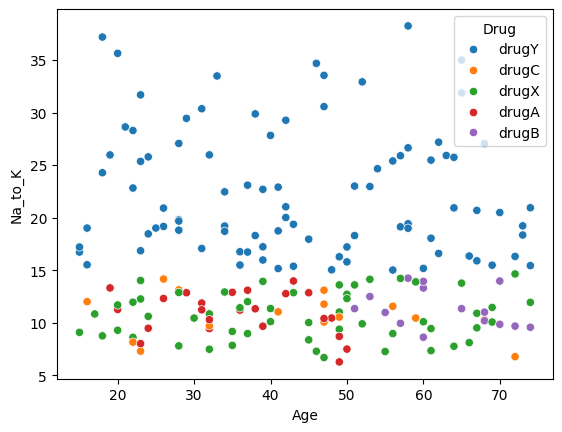

In [ ]:
sns.scatterplot(data=df, x='Age', y='Na_to_K', hue='Drug')
plt.show()

In [ ]:
df1 = df[df['Na_to_K'] >= 15]
df2 = df[df['Na_to_K'] < 15]

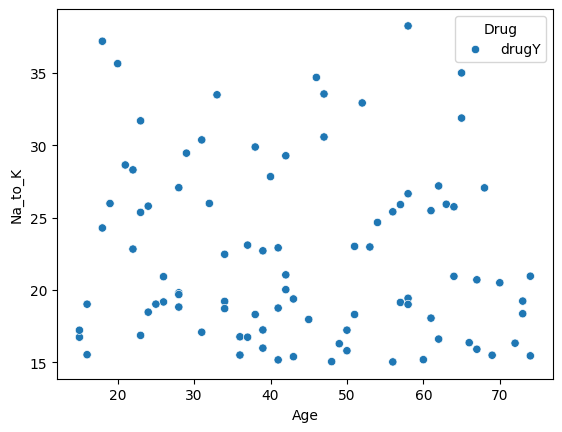

In [ ]:
sns.scatterplot(data=df1, x='Age', y='Na_to_K', hue='Drug') # to jest liść
plt.show()

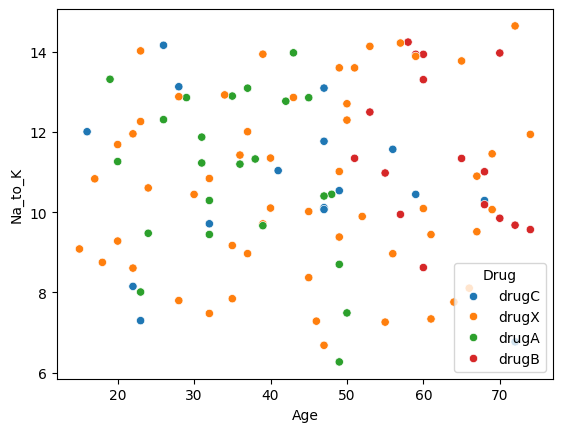

In [ ]:
sns.scatterplot(data=df2, x='Age', y='Na_to_K', hue='Drug')
plt.show()

In [ ]:
df2_1 = df2[df2['Age'] >= 50]
df2_2 = df2[df2['Age'] < 50]

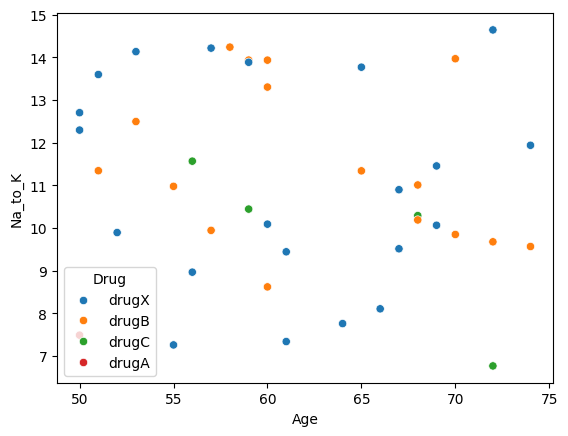

In [ ]:
sns.scatterplot(data=df2_1, x='Age', y='Na_to_K', hue='Drug')
plt.show()

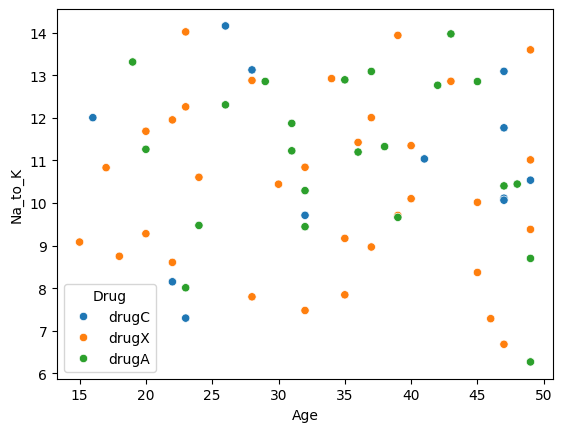

In [ ]:
sns.scatterplot(data=df2_2, x='Age', y='Na_to_K', hue='Drug')
plt.show()

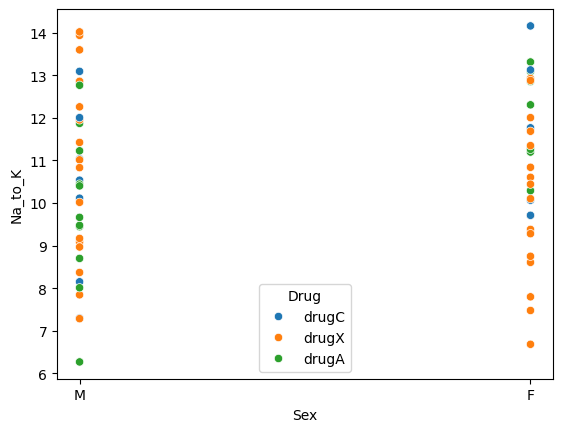

In [ ]:
sns.scatterplot(data=df2_2, x='Sex', y='Na_to_K', hue='Drug')
plt.show()

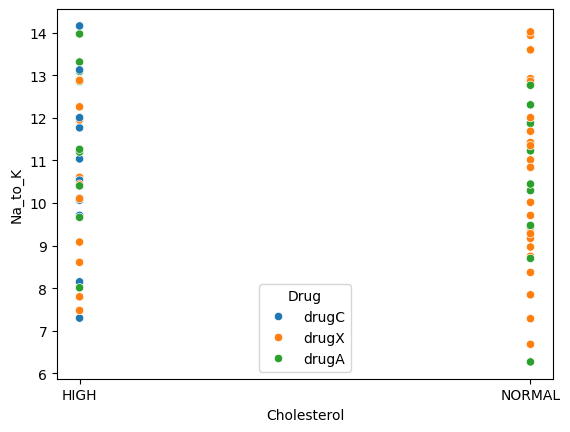

In [ ]:
sns.scatterplot(data=df2_2, x='Cholesterol', y='Na_to_K', hue='Drug')
plt.show()

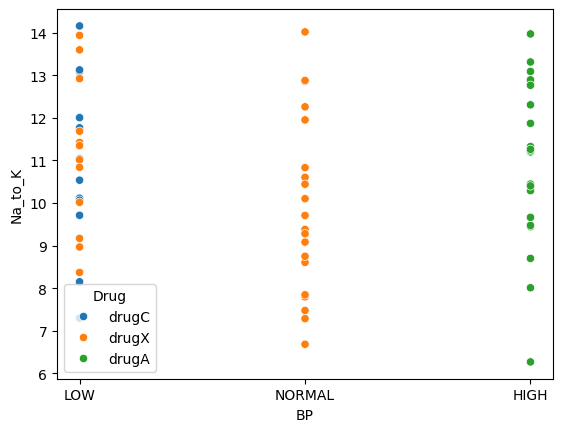

In [ ]:
sns.scatterplot(data=df2_2, x='BP', y='Na_to_K', hue='Drug')
plt.show()

<ipython-input-23-9c553955d7c3>:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df2_2_1 = df2_2[df['BP'] == 'NORMAL']


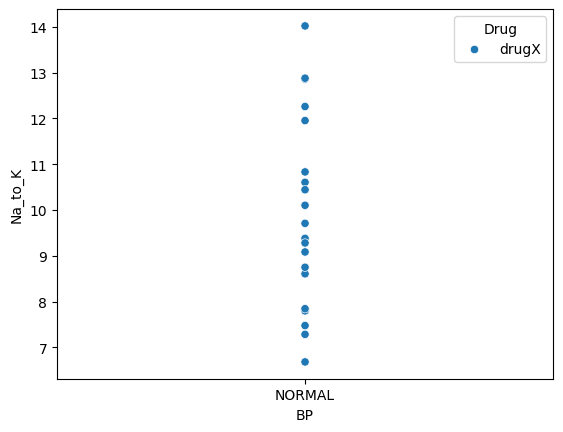

In [ ]:
df2_2_1 = df2_2[df['BP'] == 'NORMAL']  #  TO JEST LISC LEK X
sns.scatterplot(data=df2_2_1, x='BP', y='Na_to_K', hue='Drug')
plt.show()

# Zadanie: X, y: podział danych na X i y

In [ ]:
X, y = df.drop(columns='Drug'), df['Drug']

In [ ]:
X = pd.get_dummies(X, columns=['Sex', 'BP', 'Cholesterol'], drop_first=True)  #  tworzenie zmiennych dummy

# Budownie modelu drzewa decyzyjnego, binarne

In [ ]:
from sklearn.tree import DecisionTreeClassifier  #  będziemy tworzyć model klasyfikacji

In [ ]:
clf = DecisionTreeClassifier()

In [ ]:
clf.fit(X, y)

DecisionTreeClassifier()

In [ ]:
clf.score(X, y)

1.0

# Wizualizacji drzewa: graphviz
https://graphviz.org/download/

In [ ]:
from sklearn.tree import export_graphviz

In [ ]:
import graphviz

In [ ]:
clf.classes_

array(['drugA', 'drugB', 'drugC', 'drugX', 'drugY'], dtype=object)

In [ ]:
dot_data = export_graphviz(
    clf,
    out_file=None,
    class_names=clf.classes_,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    special_characters=True
    )

In [ ]:
dot_data

'digraph Tree {\nnode [shape=box, fontname="helvetica"] ;\nedge [fontname="helvetica"] ;\n0 [label="Na_to_K <= 14.829\\ngini = 0.694\\nsamples = 200\\nvalue = [23, 16, 16, 54, 91]\\nclass = drugY"] ;\n1 [label="BP_NORMAL <= 0.5\\ngini = 0.667\\nsamples = 109\\nvalue = [23, 16, 16, 54, 0]\\nclass = drugX"] ;\n0 -> 1 [labeldistance=2.5, labelangle=45, headlabel="True"] ;\n2 [label="BP_LOW <= 0.5\\ngini = 0.744\\nsamples = 73\\nvalue = [23, 16, 16, 18, 0]\\nclass = drugA"] ;\n1 -> 2 ;\n3 [label="Age <= 50.5\\ngini = 0.484\\nsamples = 39\\nvalue = [23, 16, 0, 0, 0]\\nclass = drugA"] ;\n2 -> 3 ;\n4 [label="gini = 0.0\\nsamples = 23\\nvalue = [23, 0, 0, 0, 0]\\nclass = drugA"] ;\n3 -> 4 ;\n5 [label="gini = 0.0\\nsamples = 16\\nvalue = [0, 16, 0, 0, 0]\\nclass = drugB"] ;\n3 -> 5 ;\n6 [label="Cholesterol_NORMAL <= 0.5\\ngini = 0.498\\nsamples = 34\\nvalue = [0, 0, 16, 18, 0]\\nclass = drugX"] ;\n2 -> 6 ;\n7 [label="gini = 0.0\\nsamples = 16\\nvalue = [0, 0, 16, 0, 0]\\nclass = drugC"] ;\n6 ->

In [ ]:
graph = graphviz.Source(dot_data)
graph.render("drug_tree")

'drug_tree.pdf'

Link do obliczeń współczynnika gini  
https://docs.google.com/spreadsheets/d/1ju0H2jV2QtBirVdH_XxVJQOws44ii-nnx5LiZdiSK_o/edit?gid=0#gid=0

## Zadanie, napisać kod uczenia maszynowego z podziałem na tr i ts (zbiór uczący i testowy)

In [ ]:
from sklearn.model_selection import train_test_split

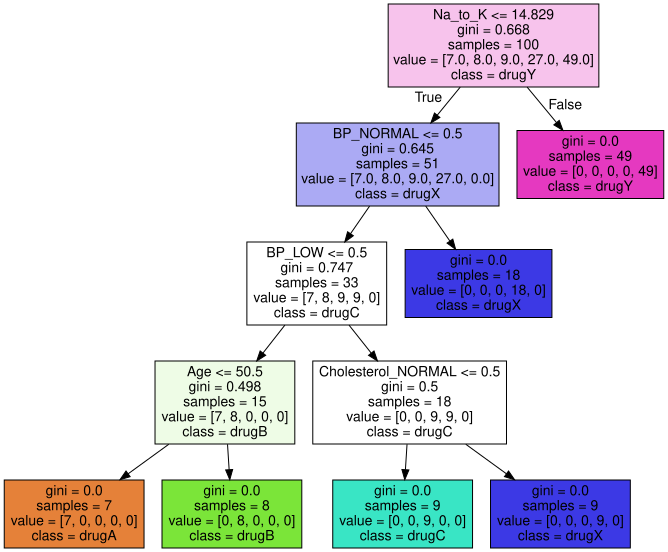

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
clf2 = DecisionTreeClassifier(random_state=42)
clf2.fit(X_train, y_train)
clf2.score(X_train, y_train)
dot_data2 = export_graphviz(clf2,
                          out_file=None,
                          class_names=clf.classes_,
                          feature_names=X.columns,
                          filled=True)
graphviz.Source(dot_data2)


In [ ]:
print(clf2.score(X_train, y_train), clf2.score(X_test, y_test))

1.0 1.0


## Strategia i  realizacja na uprodukcujnienie modelu

In [ ]:
import pickle

In [ ]:
with open('drug_tree.pkl', 'wb') as f:
    pickle.dump(clf2, f)

In [ ]:
!cat drug_tree.pkl

monotonic_cst�N�feature_names_in_��numpy.core.multiarray��_reconstruct����numpy��ndarray���K ��Cb���R�(KK��h�dtype����O8�����R�(K�|�NNNJ����J����K?t�b�]�(�Age��Na_to_K��Sex_M��BP_LOW��	BP_NORMAL��Cholesterol_NORMAL�et�b�n_features_in_�K�
n_outputs_�K�classes_�hhK ��h��R�(KK��h$�]�(�drugA��drugB��drugC��drugX��drugY�et�b�
max_features_�K�tree_��sklearn.tree._tree��Tree���KhhK ��h��R�(KK��hB�C       �t�bK��R�}�(h	K�
node_count�K�nodes�hhK ��h��R�(KK��h!�V64�����R�(Kh%N(�
left_child��right_child��feature��	threshold��impurity��n_node_samples��weighted_n_node_samples��missing_go_to_left�t�}�(h_h!�i8�����R�(KhCNNNJ����J����K t�bK ��h`hkK��hahkK��hbh!�f8�����R�(KhCNNNJ����J����K t�bK��hchrK ��hdhkK(��hehrK0��hfh!�u1�����R�(Kh%NNNJ����J����K t�bK8��uK@KKt�b�B�         
                 01�-@>�٬�\�?d             Y@              	                    �?6�E���?3            �I@                                  �?@�_)

# Przebudowa kodu

In [ ]:
from sklearn import preprocessing

In [ ]:
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [ ]:
ohe = preprocessing.OneHotEncoder(sparse_output=False)

In [ ]:
X, y = df.drop(columns='Drug'), df['Drug']

In [ ]:
X_cat = X.select_dtypes(include='object')

In [ ]:
import numpy as np

In [ ]:
X_num = X.select_dtypes(include='number')

In [ ]:
ohe.fit(X_cat)

OneHotEncoder(sparse_output=False)

In [ ]:
X_one = ohe.transform(X_cat)  # to_array

In [ ]:
X_one

array([[1., 0., 1., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 1., 0.],
       ...,
       [0., 1., 0., ..., 1., 1., 0.],
       [0., 1., 0., ..., 1., 0., 1.],
       [1., 0., 0., ..., 0., 0., 1.]])

In [ ]:
X = np.concatenate((X_num.to_numpy(), X_one), axis=1)

In [ ]:
X

array([[23.   , 25.355,  1.   , ...,  0.   ,  1.   ,  0.   ],
       [47.   , 13.093,  0.   , ...,  0.   ,  1.   ,  0.   ],
       [47.   , 10.114,  0.   , ...,  0.   ,  1.   ,  0.   ],
       ...,
       [52.   ,  9.894,  0.   , ...,  1.   ,  1.   ,  0.   ],
       [23.   , 14.02 ,  0.   , ...,  1.   ,  0.   ,  1.   ],
       [40.   , 11.349,  1.   , ...,  0.   ,  0.   ,  1.   ]])

In [ ]:
clf = DecisionTreeClassifier()

In [ ]:
clf.fit(X, y)

DecisionTreeClassifier()

In [ ]:
model = [clf, ohe]

In [ ]:
with open('drug_tree_model.pkl', 'wb') as f:
    pickle.dump(model, f)